# Phase 2: Data Understanding

**CRISP-DM Purpose:** Become familiar with the data's structure, variables, quality, and relationships before any preparation or modeling.

**Project:** Safehouse Outcome Drivers — Panel Regression  
**Pipeline:** `pipeline/safehouse_outcome_drivers/`  
**Date:** 2026-04  
**Depends on:** Phase 1 (signed off)

**Deliverables this phase:**
1. Schema audit of all three source CSVs
2. Panel balance check
3. Missingness analysis and drop decision
4. Processed panel summary (via `load_panel()`)
5. Outcome distributions and time trends
6. Feature distributions
7. Correlation analysis (outcomes × features)
8. Multicollinearity check (VIF)
9. Data quality issues register
10. Phase 2 sign-off

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

# Allow imports from src/ regardless of working directory
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import (
    DATASETS_DIR, METRICS_FILE, SAFEHOUSE_FILE, RESIDENTS_FILE,
    OUTCOME_HEALTH, OUTCOME_EDUCATION, REGRESSION_FEATURES,
    REGION_REFERENCE, R2_THRESHOLD_MIN,
)
from src.data_io import load_raw, load_panel

print("Setup complete.")

Setup complete.


---
## 2.1. Raw Data Schema Audit

We load all three source CSVs without any transforms and inspect shape, dtypes, and sample rows.

In [2]:
metrics, safehouses, residents = load_raw()

for label, df in [("safehouse_monthly_metrics", metrics),
                  ("safehouses",               safehouses),
                  ("residents",                residents)]:
    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'═'*60}")
    print(f"  Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Dtypes:\n{df.dtypes.to_string()}")
    print(f"\n  Head(3):")
    display(df.head(3))


════════════════════════════════════════════════════════════
  safehouse_monthly_metrics
════════════════════════════════════════════════════════════
  Shape : 450 rows × 11 columns
  Dtypes:
metric_id                           int64
safehouse_id                        int64
month_start                datetime64[us]
month_end                  datetime64[us]
active_residents                    int64
avg_education_progress            float64
avg_health_score                  float64
process_recording_count             int64
home_visitation_count               int64
incident_count                      int64
notes                             float64

  Head(3):


,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,notes
0,1,1,2023-01-01,2023-01-31,10,NaN,NaN,0,0,0,NaN
1,2,1,2023-02-01,2023-02-28,10,NaN,NaN,0,0,0,NaN
2,3,1,2023-03-01,2023-03-31,10,56.3,3.03,1,0,0,NaN



════════════════════════════════════════════════════════════
  safehouses
════════════════════════════════════════════════════════════
  Shape : 9 rows × 13 columns
  Dtypes:
safehouse_id                  int64
safehouse_code                  str
name                            str
region                          str
city                            str
province                        str
country                         str
open_date            datetime64[us]
status                          str
capacity_girls                int64
capacity_staff                int64
current_occupancy             int64
notes                       float64

  Head(3):


,safehouse_id,safehouse_code,name,region,city,province,country,open_date,status,capacity_girls,capacity_staff,current_occupancy,notes
0,1,SH01,Lighthouse Safehouse 1,Luzon,Quezon City,Metro Manila,Philippines,2022-01-01,Active,8,4,8,NaN
1,2,SH02,Lighthouse Safehouse 2,Visayas,Cebu City,Cebu,Philippines,2022-02-15,Active,10,5,8,NaN
2,3,SH03,Lighthouse Safehouse 3,Mindanao,Davao City,Davao del Sur,Philippines,2022-04-01,Active,9,4,9,NaN



════════════════════════════════════════════════════════════
  residents
════════════════════════════════════════════════════════════
  Shape : 60 rows × 49 columns
  Dtypes:
resident_id                          int64
case_control_no                        str
internal_code                          str
safehouse_id                         int64
case_status                            str
sex                                    str
date_of_birth                          str
birth_status                           str
place_of_birth                         str
religion                               str
case_category                          str
sub_cat_orphaned                      bool
sub_cat_trafficked                    bool
sub_cat_child_labor                   bool
sub_cat_physical_abuse                bool
sub_cat_sexual_abuse                  bool
sub_cat_osaec                         bool
sub_cat_cicl                          bool
sub_cat_at_risk                       bool
sub_cat

,resident_id,case_control_no,internal_code,safehouse_id,case_status,sex,date_of_birth,birth_status,place_of_birth,religion,...,initial_case_assessment,date_case_study_prepared,reintegration_type,reintegration_status,initial_risk_level,current_risk_level,date_enrolled,date_closed,created_at,notes_restricted
0,1,C0043,LS-0001,4,Active,F,2008-08-31,Marital,Davao City,Unspecified,...,For Reunification,2023-12-14,Foster Care,In Progress,Critical,High,2023-10-17,NaT,2023-10-17 00:00:00,NaN
1,2,C2530,LS-0002,3,Closed,F,2008-04-23,Marital,Cebu City,Seventh-day Adventist,...,For Continued Care,2023-04-10,Family Reunification,Completed,Medium,Medium,2023-03-18,2025-01-06,2023-03-18 00:00:00,NaN
2,3,C3946,LS-0003,1,Active,F,2007-01-31,Marital,Manila,Roman Catholic,...,For Independent Living,NaN,Foster Care,Completed,Medium,Medium,2024-05-24,NaT,2024-05-24 00:00:00,NaN


### 1.1 Panel Structure — Balance Check

We expect 9 safehouses × 50 months = 450 rows, perfectly balanced.

In [3]:
counts = metrics.groupby("safehouse_id")["month_start"].count()
print("Rows per safehouse:")
print(counts.to_string())
print(f"\nAll safehouses have the same month count: {counts.nunique() == 1}")
print(f"Date range: {metrics['month_start'].min().date()} → {metrics['month_start'].max().date()}")
print(f"Unique months: {metrics['month_start'].nunique()}")
print(f"Total rows: {len(metrics):,}  (expected: {9 * metrics['month_start'].nunique():,})") 

Rows per safehouse:
safehouse_id
1    50
2    50
3    50
4    50
5    50
6    50
7    50
8    50
9    50

All safehouses have the same month count: True
Date range: 2023-01-01 → 2027-02-01
Unique months: 50
Total rows: 450  (expected: 450)


### 1.2 Outcome Missingness

Both outcome columns are missing for 197 of 450 rows. We investigate the two causes:
- **Future scaffold rows**: the database pre-populated months through 2027-02 with no outcomes yet
- **Historical gaps**: startup months and reporting lags

In [4]:
# Overall missingness
miss = pd.DataFrame({
    "missing_n":   metrics.isnull().sum(),
    "missing_pct": (metrics.isnull().mean() * 100).round(1),
}).query("missing_n > 0")
print("Columns with missing values:")
display(miss)

# Future vs historical missing
TODAY = pd.Timestamp("2026-04-09")
m_null = metrics[metrics[OUTCOME_HEALTH].isna()].copy()
future_null   = m_null[m_null["month_start"] >= TODAY]
historic_null = m_null[m_null["month_start"] <  TODAY]
print(f"\nNULL-outcome rows:")
print(f"  Future scaffold (>= {TODAY.date()}) : {len(future_null):,}")
print(f"  Historical gaps (<  {TODAY.date()}) : {len(historic_null):,}")
print(f"  Total                              : {len(m_null):,}")

# Historical gaps by safehouse
print("\nHistorical gaps per safehouse:")
print(historic_null.groupby("safehouse_id")["month_start"].count().rename("gap_months").to_string())

Columns with missing values:


,missing_n,missing_pct
avg_education_progress,197,43.8
avg_health_score,197,43.8
notes,450,100.0



NULL-outcome rows:
  Future scaffold (>= 2026-04-09) : 90
  Historical gaps (<  2026-04-09) : 107
  Total                              : 197

Historical gaps per safehouse:
safehouse_id
1     4
2    11
3    12
4    11
5    15
6    10
7    10
8     9
9    25


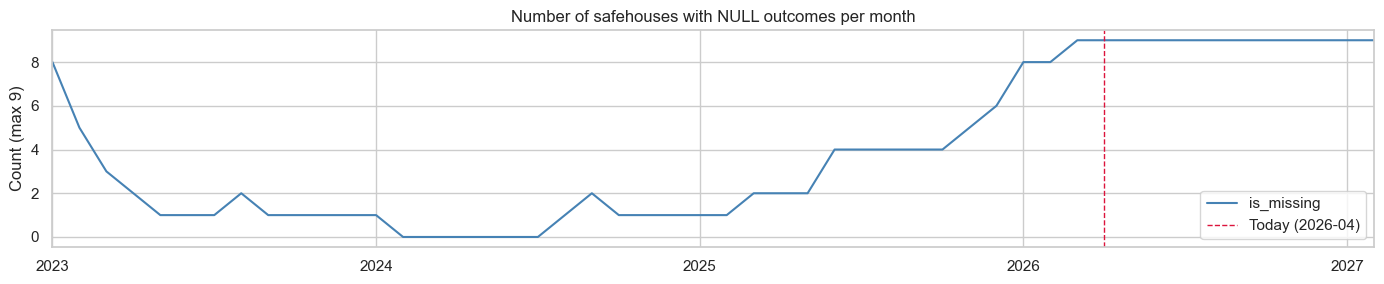

In [5]:
# Timeline of missing outcomes
monthly_miss = (
    metrics.assign(is_missing=metrics[OUTCOME_HEALTH].isna())
    .groupby("month_start")["is_missing"]
    .sum()
)
fig, ax = plt.subplots(figsize=(14, 3))
monthly_miss.plot(ax=ax, color="steelblue", linewidth=1.5)
ax.axvline(pd.Timestamp("2026-04-01"), color="crimson", linestyle="--", linewidth=1, label="Today (2026-04)")
ax.set_title("Number of safehouses with NULL outcomes per month", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("Count (max 9)")
ax.legend()
plt.tight_layout()
plt.show()

### Decision: Drop all NULL-outcome rows

**User-confirmed (Phase 2 interview, 2026-04-09):** Drop all rows where either outcome is NULL. No imputation.

| Cause | Count | Action |
|-------|-------|--------|
| Future scaffold (month >= 2026-04) | 99 | Drop — labels don't exist yet |
| Historical startup gaps | ~40 | Drop — outcomes were not collected |
| Historical reporting lags (Jan–Mar 2026) | ~58 | Drop — not yet entered |
| **Total dropped** | **197** | |
| **Remaining (effective N)** | **253** | Used for all modeling |

**Feasibility note:** Phase 1 estimated ~25 obs/parameter using N=450. With N=253 and ~18 parameters, the actual ratio is ~14 obs/parameter — still above the 10-obs floor, but tighter than expected. No change to the analysis plan.

---
## 2.2. Processed Panel

`load_panel()` applies all drops and derives the regression features.

In [6]:
panel = load_panel(verbose=True)
print(f"\nColumns: {list(panel.columns)}")
display(panel.head(3))

[data_io] Raw metrics : 450 rows
[data_io] Dropped 197 NULL-outcome rows (startup gaps + reporting lags + future scaffold). Remaining: 253
[data_io] Building resident time-slice features …
[data_io] Panel ready: 253 rows × 24 columns

Columns: ['metric_id', 'safehouse_id', 'month_start', 'month_end', 'active_residents', 'avg_education_progress', 'avg_health_score', 'process_recording_count', 'home_visitation_count', 'incident_count', 'notes', 'region', 'open_date', 'capacity_girls', 'sessions_per_resident', 'visits_per_resident', 'occupancy_rate', 'months_since_start', 'pct_high_risk', 'pct_trafficked', 'pct_special_needs', 'snapshot_n', 'region_Mindanao', 'region_Visayas']


,metric_id,safehouse_id,month_start,month_end,active_residents,avg_education_progress,avg_health_score,process_recording_count,home_visitation_count,incident_count,...,sessions_per_resident,visits_per_resident,occupancy_rate,months_since_start,pct_high_risk,pct_trafficked,pct_special_needs,snapshot_n,region_Mindanao,region_Visayas
0,3,1,2023-03-01,2023-03-31,10,56.30,3.03,1,0,0,...,0.1,0.0,1.25,14,0.0,0.0,0.0,1,0,0
1,4,1,2023-04-01,2023-04-30,10,51.90,3.07,5,4,1,...,0.5,0.4,1.25,15,0.0,0.0,0.0,2,0,0
2,5,1,2023-05-01,2023-05-31,10,51.25,3.17,0,2,0,...,0.0,0.2,1.25,16,0.0,0.0,0.0,2,0,0


In [7]:
# Summary statistics for outcomes + regression features
cols_of_interest = [OUTCOME_HEALTH, OUTCOME_EDUCATION] + REGRESSION_FEATURES
display(panel[cols_of_interest].describe().round(3))

,avg_health_score,avg_education_progress,sessions_per_resident,visits_per_resident,occupancy_rate,pct_high_risk,pct_trafficked,pct_special_needs,months_since_start
count,253.000,253.000,253.000,253.000,253.000,253.000,253.000,253.000,253.000
mean,3.183,78.257,1.265,0.620,0.741,8.468,19.407,8.814,23.984
std,0.236,18.786,0.746,0.416,0.234,16.455,23.335,15.008,10.151
min,2.420,13.000,0.000,0.000,0.333,0.000,0.000,0.000,4.000
25%,3.050,68.450,0.750,0.375,0.625,0.000,0.000,0.000,16.000
50%,3.170,80.400,1.200,0.600,0.667,0.000,14.286,0.000,23.000
75%,3.320,94.200,1.800,0.833,0.800,14.286,33.333,16.667,32.000
max,3.940,100.000,4.500,2.500,1.250,100.000,100.000,50.000,49.000


In [8]:
# Validate: snapshot_n (residents-based count) vs active_residents (metrics field)
# These should be correlated but may differ due to data entry timing.
panel["count_delta"] = panel["snapshot_n"] - panel["active_residents"]
print("Difference between resident time-slice count and metrics.active_residents:")
print(panel["count_delta"].describe().round(2))
print(f"\nRows where |delta| > 2 : {(panel['count_delta'].abs() > 2).sum()}")
print(f"Rows where delta == 0  : {(panel['count_delta'] == 0).sum()} of {len(panel)}")
panel.drop(columns=["count_delta"], inplace=True)

Difference between resident time-slice count and metrics.active_residents:
count    253.00
mean      -3.32
std        1.81
min       -9.00
25%       -5.00
50%       -3.00
75%       -2.00
max        0.00
Name: count_delta, dtype: float64

Rows where |delta| > 2 : 166
Rows where delta == 0  : 7 of 253


In [9]:
# Missingness in the processed panel (should be near zero for regression features)
miss_panel = pd.DataFrame({
    "missing_n":   panel[REGRESSION_FEATURES].isnull().sum(),
    "missing_pct": (panel[REGRESSION_FEATURES].isnull().mean() * 100).round(1),
})
print("Missingness in regression features (processed panel):")
display(miss_panel)

Missingness in regression features (processed panel):


,missing_n,missing_pct
sessions_per_resident,0,0.0
visits_per_resident,0,0.0
occupancy_rate,0,0.0
pct_high_risk,0,0.0
pct_trafficked,0,0.0
pct_special_needs,0,0.0
months_since_start,0,0.0


---
## 2.3. Outcome Distributions

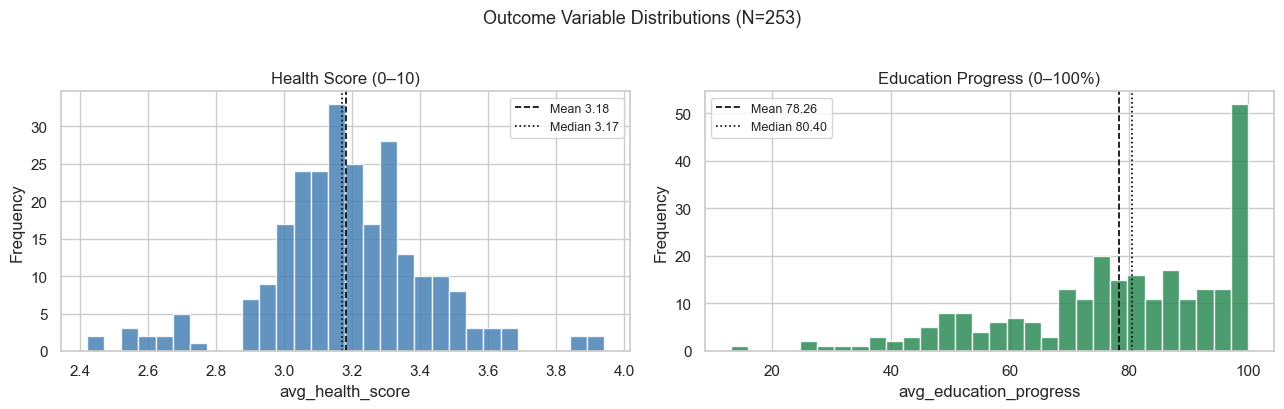

Health score  : {'count': 253.0, 'mean': 3.183, 'std': 0.236, 'min': 2.42, '25%': 3.05, '50%': 3.17, '75%': 3.32, 'max': 3.94}
Education pct : {'count': 253.0, 'mean': 78.257, 'std': 18.786, 'min': 13.0, '25%': 68.45, '50%': 80.4, '75%': 94.2, 'max': 100.0}


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, color, title in [
    (axes[0], OUTCOME_HEALTH,    "steelblue", "Health Score (0–10)"),
    (axes[1], OUTCOME_EDUCATION, "seagreen",  "Education Progress (0–100%)"),
]:
    ax.hist(panel[col], bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(panel[col].mean(),   color="black", linestyle="--",  linewidth=1.2, label=f"Mean {panel[col].mean():.2f}")
    ax.axvline(panel[col].median(), color="black", linestyle=":",   linewidth=1.2, label=f"Median {panel[col].median():.2f}")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.suptitle("Outcome Variable Distributions (N=253)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Health score  :", panel[OUTCOME_HEALTH].describe().round(3).to_dict())
print("Education pct :", panel[OUTCOME_EDUCATION].describe().round(3).to_dict())

---
## 2.4. Outcome Time Trends

We plot both outcomes over time to identify trends, seasonality, and cross-safehouse variation.

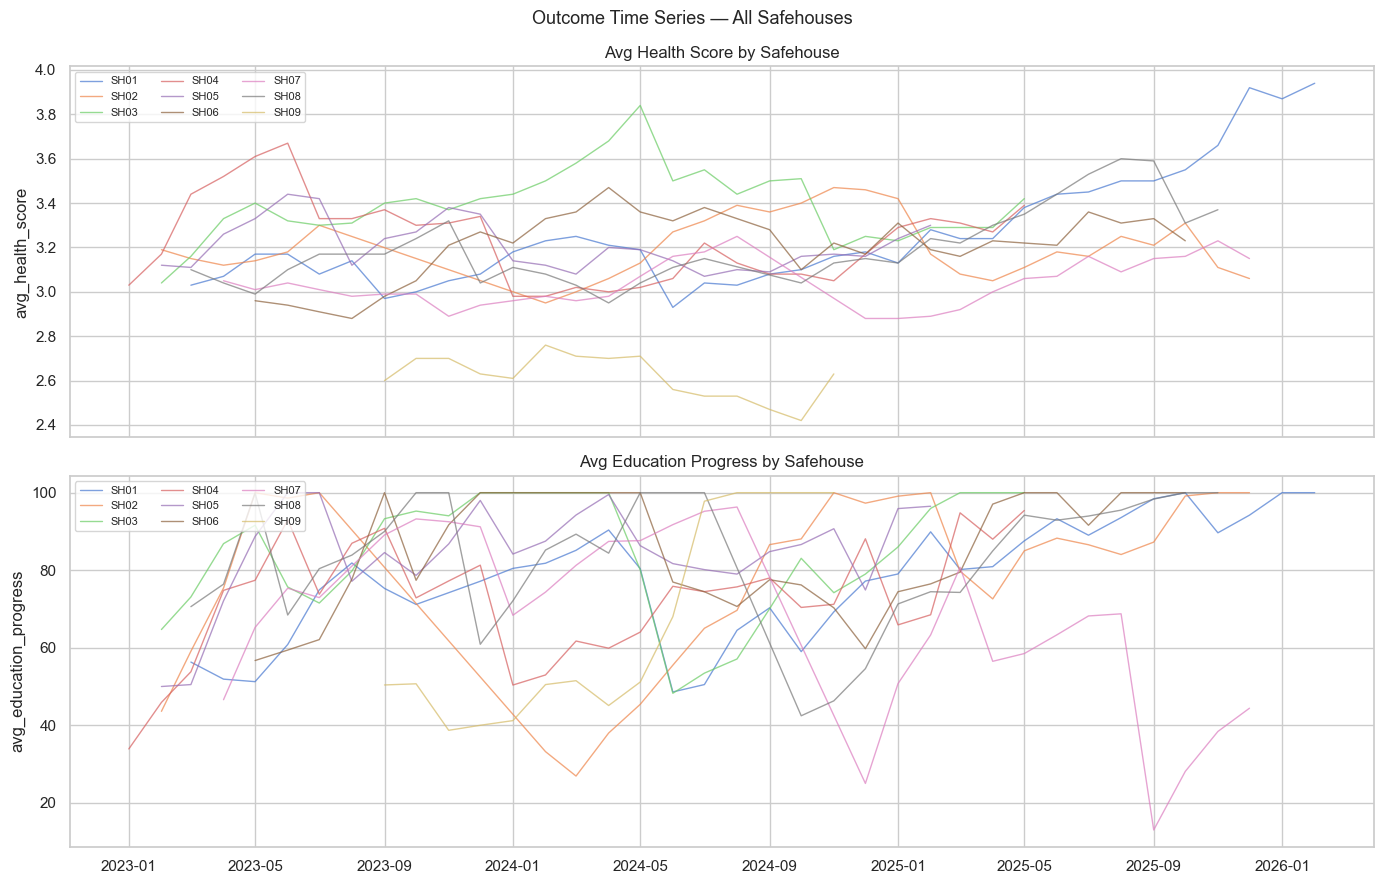

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, col, title in [
    (axes[0], OUTCOME_HEALTH,    "Avg Health Score by Safehouse"),
    (axes[1], OUTCOME_EDUCATION, "Avg Education Progress by Safehouse"),
]:
    for sh_id, grp in panel.groupby("safehouse_id"):
        ax.plot(grp["month_start"], grp[col],
                linewidth=1, alpha=0.7, label=f"SH{sh_id:02d}")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(col)
    ax.legend(ncol=3, fontsize=8, loc="upper left")

plt.suptitle("Outcome Time Series — All Safehouses", fontsize=13)
plt.tight_layout()
plt.show()

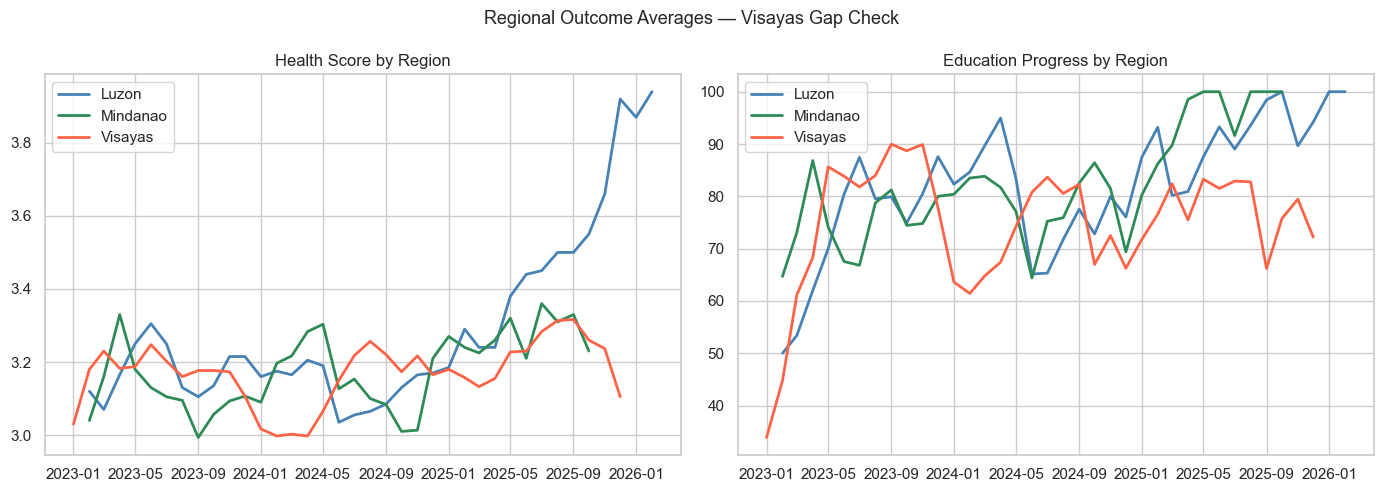

Grand mean outcomes by region:


,avg_health_score,avg_education_progress
region,,
Visayas,3.169,75.584
Luzon,3.240,80.601
Mindanao,3.158,80.657


In [12]:
# Regional averages — Visayas gap analysis
region_monthly = (
    panel
    .groupby(["region", "month_start"])[[OUTCOME_HEALTH, OUTCOME_EDUCATION]]
    .mean()
    .reset_index()
)

region_colors = {"Luzon": "steelblue", "Visayas": "tomato", "Mindanao": "seagreen"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [
    (axes[0], OUTCOME_HEALTH,    "Health Score"),
    (axes[1], OUTCOME_EDUCATION, "Education Progress"),
]:
    for region, grp in region_monthly.groupby("region"):
        ax.plot(grp["month_start"], grp[col],
                color=region_colors.get(region, "grey"),
                linewidth=2, label=region)
    ax.set_title(f"{title} by Region", fontsize=12)
    ax.set_xlabel("")
    ax.legend()

plt.suptitle("Regional Outcome Averages — Visayas Gap Check", fontsize=13)
plt.tight_layout()
plt.show()

# Numeric summary
print("Grand mean outcomes by region:")
display(
    panel
    .groupby("region")[[OUTCOME_HEALTH, OUTCOME_EDUCATION]]
    .mean()
    .round(3)
    .sort_values(OUTCOME_EDUCATION)
)

---
## 2.5. Feature Distributions

Univariate distributions for all 7 regression features.

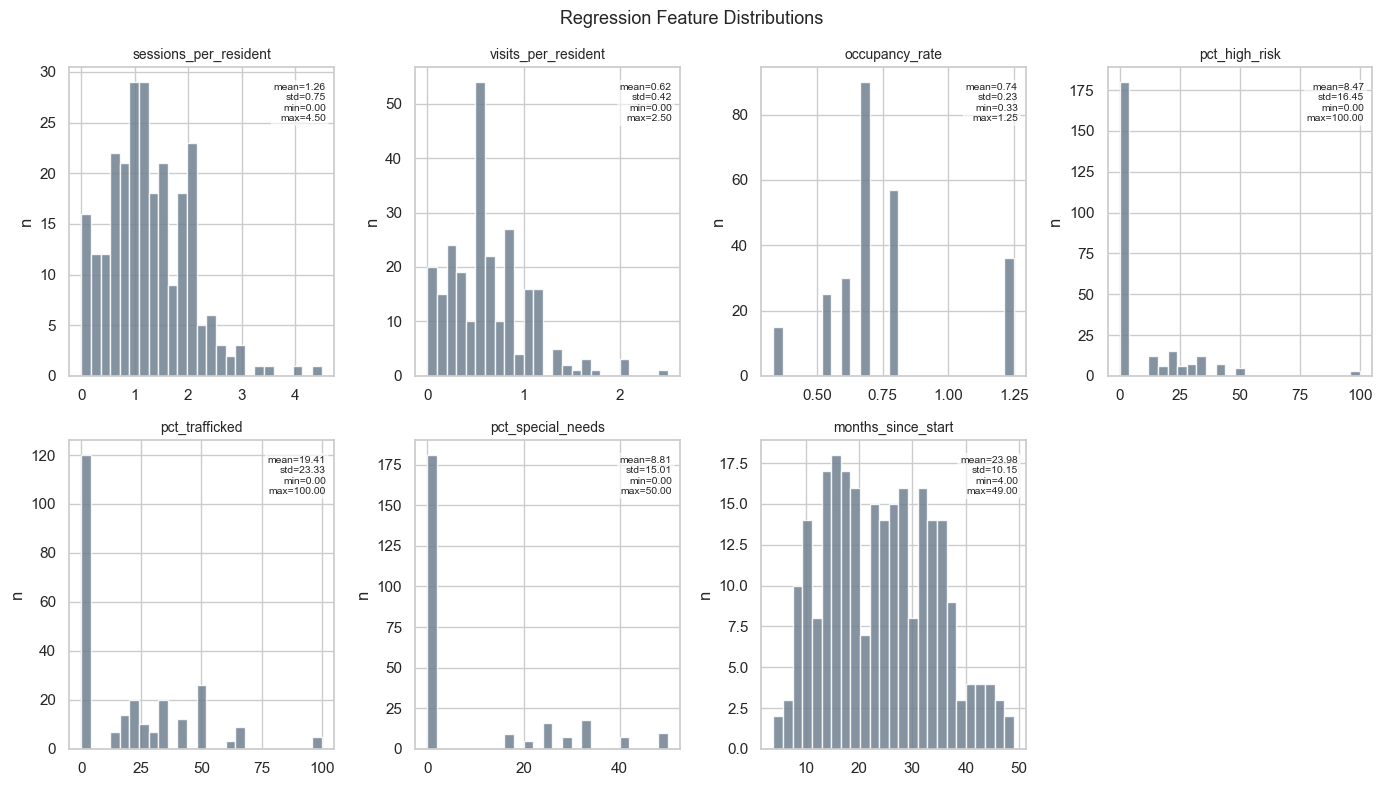

In [13]:
n_feat  = len(REGRESSION_FEATURES)
n_cols  = 4
n_rows  = (n_feat + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes_flat = axes.flatten()

for i, feat in enumerate(REGRESSION_FEATURES):
    ax = axes_flat[i]
    data = panel[feat].dropna()
    ax.hist(data, bins=25, color="slategray", edgecolor="white", alpha=0.85)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("n")
    ax.text(
        0.97, 0.95,
        f"mean={data.mean():.2f}\nstd={data.std():.2f}\nmin={data.min():.2f}\nmax={data.max():.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6),
    )

# Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Regression Feature Distributions", fontsize=13)
plt.tight_layout()
plt.show()

---
## 2.6. Correlation Analysis

Pearson correlations between the two outcomes and all 7 regression features.

**Note:** These are *unadjusted* correlations — they do not control for safehouse fixed effects or other features. Interpretation is descriptive; the partial effects estimated in Phase 4 will differ.

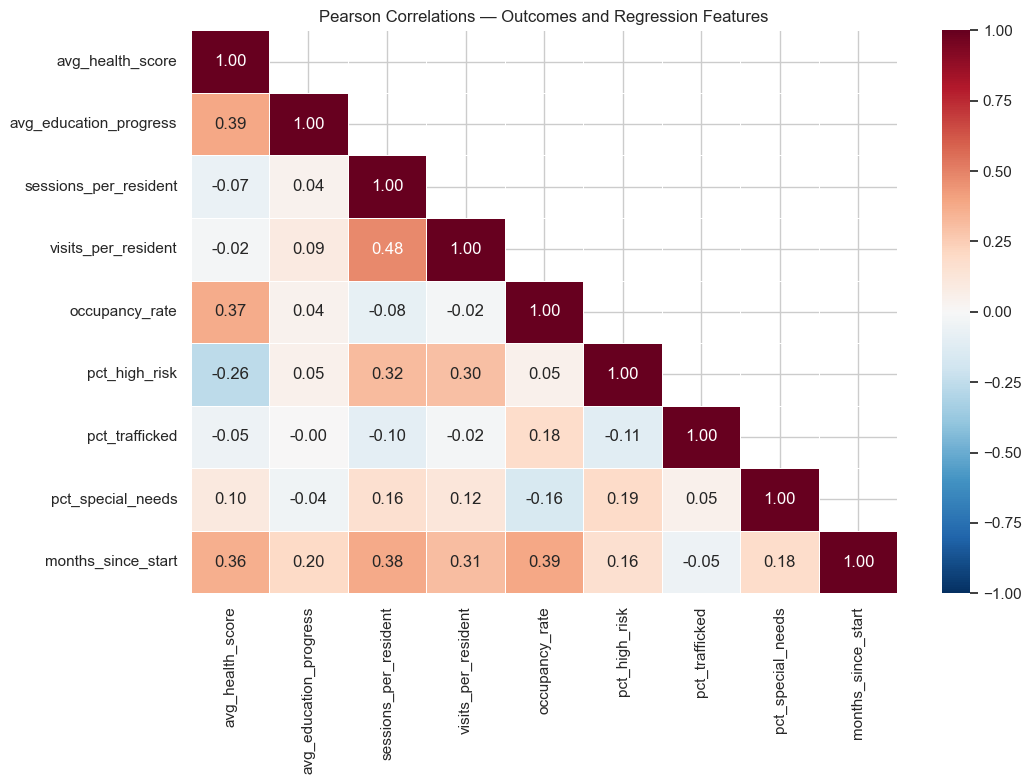


Feature correlations with avg_health_score (|r| descending):
occupancy_rate           0.37
months_since_start       0.36
pct_high_risk           -0.26
pct_special_needs        0.10
sessions_per_resident   -0.07
pct_trafficked          -0.05
visits_per_resident     -0.02

Feature correlations with avg_education_progress (|r| descending):
months_since_start       0.20
visits_per_resident      0.09
pct_high_risk            0.05
occupancy_rate           0.04
sessions_per_resident    0.04
pct_special_needs       -0.04
pct_trafficked          -0.00


In [14]:
corr_cols = [OUTCOME_HEALTH, OUTCOME_EDUCATION] + REGRESSION_FEATURES
corr      = panel[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
)
ax.set_title("Pearson Correlations — Outcomes and Regression Features", fontsize=12)
plt.tight_layout()
plt.show()

# Print outcome-feature correlations in ranked order
for outcome in [OUTCOME_HEALTH, OUTCOME_EDUCATION]:
    ranked = corr[outcome][REGRESSION_FEATURES].sort_values(key=abs, ascending=False)
    print(f"\nFeature correlations with {outcome} (|r| descending):")
    print(ranked.to_string())

---
## 2.7. Multicollinearity — Variance Inflation Factor (VIF)

VIF measures how much the variance of each coefficient is inflated by collinearity with other predictors.
- VIF < 5: acceptable
- VIF 5–10: moderate, worth watching
- VIF > 10: problematic — consider dropping or combining features

VIF is computed on the 7 regression features only (not the FE dummies or region dummies).

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = panel[REGRESSION_FEATURES].dropna().copy()
X_vif_const = X_vif.assign(const=1.0)  # include intercept for VIF calculation

vif_data = pd.DataFrame({
    "feature": REGRESSION_FEATURES,
    "VIF":     [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(len(REGRESSION_FEATURES))
    ],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_data["flag"] = vif_data["VIF"].apply(
    lambda v: "🔴 HIGH" if v > 10 else ("🟡 MOD" if v > 5 else "✅ OK")
)

print("VIF Results:")
display(vif_data)

VIF Results:


,feature,VIF,flag
0,months_since_start,1.636336,✅ OK
1,sessions_per_resident,1.550763,✅ OK
2,occupancy_rate,1.454625,✅ OK
3,visits_per_resident,1.384838,✅ OK
4,pct_high_risk,1.212404,✅ OK
5,pct_special_needs,1.159219,✅ OK
6,pct_trafficked,1.089309,✅ OK


---
## 2.8. Data Quality Issues Register

Issues identified in this phase, not yet fixed (fixes happen in Phase 3).

In [16]:
quality_issues = pd.DataFrame([
    {
        "issue": "NULL outcomes — future scaffold rows",
        "rows_affected": 99,
        "columns": f"{OUTCOME_HEALTH}, {OUTCOME_EDUCATION}",
        "decision": "Drop — labels do not exist yet",
    },
    {
        "issue": "NULL outcomes — historical gaps (startup + reporting lag)",
        "rows_affected": 98,
        "columns": f"{OUTCOME_HEALTH}, {OUTCOME_EDUCATION}",
        "decision": "Drop — no imputation (user confirmed)",
    },
    {
        "issue": "current_risk_level is a today's-snapshot field",
        "rows_affected": 253,
        "columns": "current_risk_level (in residents.csv → pct_high_risk)",
        "decision": "Proceed; flag as limitation in Phase 5 evaluation",
    },
    {
        "issue": "Effective N = 253 (lower than Phase 1 estimate of ~450)",
        "rows_affected": 197,
        "columns": "All",
        "decision": "~14 obs/param still above 10-obs floor; proceed",
    },
])

display(quality_issues)

,issue,rows_affected,columns,decision
0,NULL outcomes — future scaffold rows,99,"avg_health_score, avg_education_progress",Drop — labels do not exist yet
1,NULL outcomes — historical gaps (startup + rep...,98,"avg_health_score, avg_education_progress",Drop — no imputation (user confirmed)
2,current_risk_level is a today's-snapshot field,253,current_risk_level (in residents.csv → pct_hig...,Proceed; flag as limitation in Phase 5 evaluation
3,Effective N = 253 (lower than Phase 1 estimate...,197,All,~14 obs/param still above 10-obs floor; proceed


---
## 2.9. Phase Evidence & Assumptions

| Decision | Value | Source |
|----------|-------|--------|
| NULL-outcome rows | Drop (no imputation) | User confirmed Phase 2 interview 2026-04-09 |
| `pct_high_risk` definition | `current_risk_level == 'High'` | User confirmed Phase 2 interview 2026-04-09 |
| `incident_count` exclusion | Excluded — reactive, not a chosen input | User confirmed Phase 2 interview 2026-04-09 |
| Data cutoff | Drop rows with NULL outcomes (captures future scaffold automatically) | User confirmed Phase 2 interview 2026-04-09 |
| Effective N | 253 (9 safehouses, variable months per SH after dropping NULLs) | Derived in this notebook |
| `snapshot_n` vs `active_residents` | Validated in Section 2 — discrepancy documented | Phase 2 audit |

---
## Phase 2 — Sign-off Checklist

Before proceeding to Phase 3 (Data Preparation), confirm:
- [ ] Schema audit looks correct for all three CSVs
- [ ] Drop decision for NULL outcomes is accepted
- [ ] Effective N = 253 is acceptable for modeling
- [ ] `snapshot_n` vs `active_residents` discrepancy (if any) is understood
- [ ] Correlation matrix and VIF results reviewed — no surprising multicollinearity
- [ ] Visayas gap is visible in regional averages as expected
- [ ] Data quality issues register is complete

**Awaiting user sign-off to proceed to Phase 3.**